## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [1]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [8]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Xử lý dữ liệu và nhóm lại các biến theo các danh mục khác nhau. Trong số này:
- evap: Tốc độ bốc hơi thực tế từ bề mặt (kg/m²/s)
- pevap: Nhu cầu bốc hơi của khí quyển (kg/m²/s)
- daily_evap: Lượng bốc hơi thực tế mỗi ngày
- daily_pevap: Lượng bốc hơi có thể xảy ra nếu không bị giới hạn mỗi ngày
- daily_ef: Tỉ lệ giữa lượng bốc hơi thực tế và khả năng bốc hơi tối đa (daily_evap / daily_pevap)
- daily_def: Lượng bốc hơi bị thiếu hụt (daily_pevap - daily_evap)
- monthly_evap, monthly_pevap, monthly_ef: Tương tự, là các chỉ số theo tháng trong 45 năm
- clim_evap, clim_pevap, clim_ef: Chỉ số khí hậu của từng tháng sau khi đã tính trung bình trong suốt 45 năm
- anom_evap, anom_ef: Độ lệch so với điều kiện trung bình

Sau đó, nhóm các dữ liệu liên quan đến nhau thành một Pandas DataFrame

In [3]:
def get_evaporation_data_optimized(folder_path, evap_name, pevap_name):
    # Load datasets
    ds_evap = preprocess(xr.open_dataset(os.path.join(folder_path, evap_name)))
    ds_pevap = preprocess(xr.open_dataset(os.path.join(folder_path, pevap_name)))

    # Extract variables safely
    var_evap = list(ds_evap.data_vars)[0]
    var_pevap = list(ds_pevap.data_vars)[0]

    evap = ds_evap[var_evap]
    pevap = ds_pevap[var_pevap]

    # Spatial mean reduction
    evap = evap.mean(dim=['latitude', 'longitude'])
    pevap = pevap.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    # Multiply by -1 because in ERA5, evaporation means "negative", so we have to make it "positive"
    daily_evap = -(evap  * 86400).resample(time="1D").mean()
    daily_pevap = -(pevap * 86400).resample(time="1D").mean()

    # Only compute at this time, to maximize laziness
    daily_evap, daily_pevap = dask.compute(daily_evap, daily_pevap)

    # Close datasets
    ds_evap.close()
    ds_pevap.close()

    # Create derived variables
    daily_ef = (daily_evap / (daily_pevap + 1e-9)).clip(0, 1)
    daily_def = daily_pevap - daily_evap

    # Create monthly figures
    monthly_evap = daily_evap.resample(time="1ME").mean()
    monthly_pevap = daily_pevap.resample(time="1ME").mean()
    monthly_ef = daily_ef.resample(time="1ME").mean()

    # Create climatology figures
    clim_evap = daily_evap.groupby("time.month").mean("time")
    clim_pevap = daily_pevap.groupby("time.month").mean("time")
    clim_ef = daily_ef.groupby("time.month").mean("time")

    # Create anomalies figures
    anom_evap = daily_evap.groupby("time.month") - clim_evap
    anom_ef = daily_ef.groupby("time.month") - clim_ef

    # Group 1D DataArray into a Dataset, then convert the whole to Pandas DataFrame
    df_daily = xr.Dataset({
        "evap": daily_evap,
        "pevap": daily_pevap,
        "ef": daily_ef,
        "def": daily_def,
        "evap_anom": anom_evap,
        "ef_anom": anom_ef
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "evap": monthly_evap,
        "pevap": monthly_pevap,
        "ef": monthly_ef
    }).to_dataframe()

    df_clim = xr.Dataset({
        "evap": clim_evap,
        "pevap": clim_pevap,
        "ef": clim_ef
    }).to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim

In [4]:
df_daily, df_monthly, df_clim = get_evaporation_data_optimized(FOLDER_PATH, "mean_evaporation_rate_merged.nc", "mean_potential_evaporation_rate_merged.nc")

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,evap,pevap,ef,def,month,evap_anom,ef_anom
0,1980-01-01,2.034989,3.134266,0.649271,1.099277,1,-0.718473,-0.230320
1,1980-01-02,2.107269,3.203793,0.657742,1.096524,1,-0.646193,-0.221849
2,1980-01-03,2.270085,3.265077,0.695262,0.994992,1,-0.483376,-0.184329
3,1980-01-04,3.185475,3.216059,0.990490,0.030584,1,0.432014,0.110899
4,1980-01-05,3.427965,3.025299,1.000000,-0.402666,1,0.674503,0.120409


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,evap,pevap,ef
0,1980-01-31,2.660981,3.082984,0.841268
1,1980-02-29,2.430070,3.193520,0.753712
2,1980-03-31,2.325328,3.900636,0.603533
3,1980-04-30,2.819674,3.809826,0.733573
4,1980-05-31,3.501459,3.069372,0.958864


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,evap,pevap,ef
0,1,2.753462,2.818304,0.879591
1,2,2.453286,3.244302,0.741131
2,3,2.494061,3.611941,0.692943
3,4,2.909038,3.643781,0.795418
4,5,3.419078,3.129732,0.958461


## 1. Lượng bốc hơi thực tế và lượng bốc hơi tiềm năng

Lượng bốc hơi thực tế và tiềm năng được đo trung bình các tháng qua 45 năm, được plot trên 2 đường và khoảng cách giữa chúng chỉ sự thâm hụt bốc hơi. Nếu sự thâm hụt lớn, tức là khu vực bề mặt này đang có sự mất cân bằng về độ ẩm. Vào các tháng có lượng mưa nhiều thì lượng bốc hơi thực tế có thể sẽ cân bằng với lượng bốc hơi tiềm năng. Ngược lại, vào các tháng khô hạn, thì lượng bốc hơi thực tế sẽ cao hơn hoặc thấp hơn nhiều so với lượng bốc hơi tiềm năng.

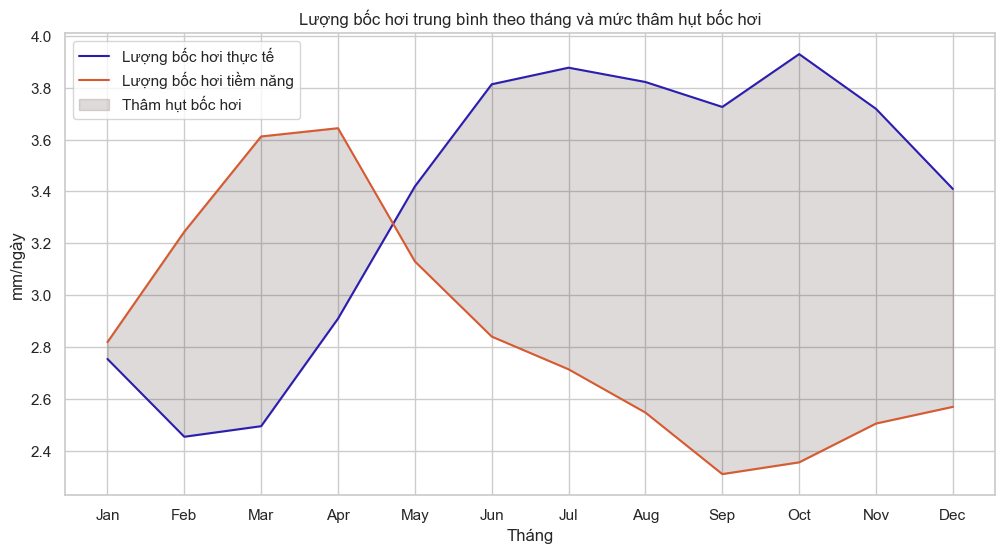

In [13]:
months = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Lượng bốc hơi trung bình theo tháng và mức thâm hụt bốc hơi")
ax.plot(months, df_clim['evap'].values,  label="Lượng bốc hơi thực tế", color="#2B1DB1")
ax.plot(months, df_clim['pevap'].values, label="Lượng bốc hơi tiềm năng", color="#D85A30")
ax.fill_between(months, df_clim['evap'].values, df_clim['pevap'].values,
                alpha=0.15, color="#270D04", label="Thâm hụt bốc hơi")
ax.set_xticks(months)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("mm/ngày")
ax.set_xlabel("Tháng")
ax.legend()

## 2. 